In [49]:
import torch
def gaussian_kernel_2d(sigma, kernel_size=6):
    if kernel_size is None:
        raise ValueError("No kernel provided")
    ax = torch.arange(kernel_size, dtype=torch.float32) - (kernel_size - 1) / 2.0
    x, y = torch.meshgrid(ax, ax, indexing='ij')
    print(x)
    k = torch.exp(-(x ** 2 + y ** 2) / (2 * sigma ** 2))
    k = k / k.sum()
    return k[None, None, :, :]
k=gaussian_kernel_2d(sigma=0.5)


tensor([[-2.5000, -2.5000, -2.5000, -2.5000, -2.5000, -2.5000],
        [-1.5000, -1.5000, -1.5000, -1.5000, -1.5000, -1.5000],
        [-0.5000, -0.5000, -0.5000, -0.5000, -0.5000, -0.5000],
        [ 0.5000,  0.5000,  0.5000,  0.5000,  0.5000,  0.5000],
        [ 1.5000,  1.5000,  1.5000,  1.5000,  1.5000,  1.5000],
        [ 2.5000,  2.5000,  2.5000,  2.5000,  2.5000,  2.5000]])


In [50]:
kernel_size=6
torch.arange(kernel_size, dtype=torch.float32)

tensor([0., 1., 2., 3., 4., 5.])

In [51]:
for sigma in [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]:
    kernel_size = int(4 * sigma + 1) | 1
    print(kernel_size)

1
1
3
3
3
3
3
5
5


In [52]:

def gaussian_blur_torch(img_2d, sigma):
    if sigma <= 0:
        return img_2d
    kernel = gaussian_kernel_2d(sigma)
    kernel = kernel.to(img_2d.device)
    padding = kernel.shape[-1] // 2
    img_4d = img_2d[None, None, :, :]
    return F.conv2d(img_4d, kernel, padding=padding)[0, 0]


def img_to_encoder_torch(img):
    return torch.flip(img.T, dims=[-1])


In [53]:
ax=torch.arange(1,5,dtype=torch.float32)
optotype1=torch.arange(1,17).reshape(4,4)
print(optotype1)

tensor([[ 1,  2,  3,  4],
        [ 5,  6,  7,  8],
        [ 9, 10, 11, 12],
        [13, 14, 15, 16]])


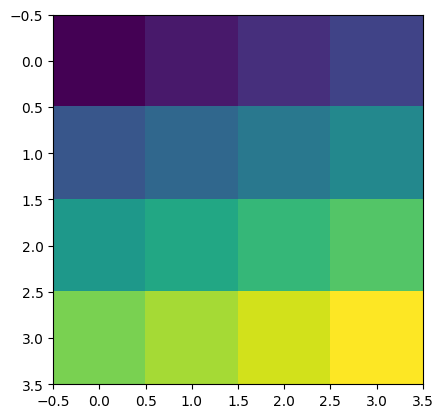

In [54]:
import matplotlib.pyplot as plt
plt.imshow(optotype1)


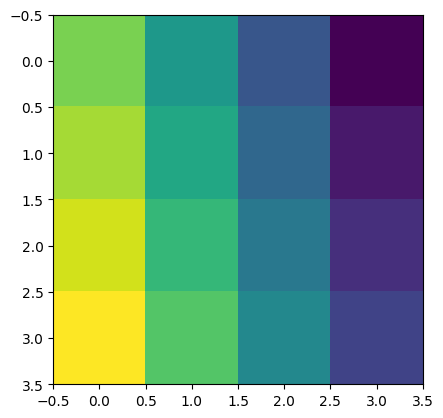

In [55]:
import numpy as np
def fit( optotype, blur_sigma=0.0):
    if optotype.dim() == 3:
        optotype = optotype.squeeze(0)
    h, _ = optotype.shape
    half_n = h // 2
    blurred = gaussian_blur_torch(optotype, blur_sigma)
    optotype_display = blurred.cpu().numpy()
    #plt.imshow(blurred.cpu().numpy().T)
    optotype_np = np.fliplr(blurred.cpu().numpy().T)
    #plt.imshow(optotype_np)
    optotype_torch = img_to_encoder_torch(blurred)
    plt.imshow(optotype_torch)


fit(optotype1)

In [58]:

dt=0.01
T=0.750
D_diff=10

def simulate_random_walk( T):
    n_steps = int(T / dt)
    sigma = np.sqrt(D_diff * dt)
    disp = np.random.normal(0.0, sigma, size=(n_steps, 2))
    walk = np.vstack([np.zeros((1, 2)), np.cumsum(disp, axis=0)])
    return walk
walk=simulate_random_walk(T)
print(walk[:,0])


[ 0.         -0.05689419 -0.12351921  0.6496909   0.93686521  1.71860711
  2.54970604  2.04389752  1.64721168  1.93627055  1.99575373  2.20003117
  2.5482858   2.17638365  2.02258054  1.92860079  1.87750029  1.92899858
  1.18507805  1.89880519  1.2458425   1.63690769  1.47295861  1.50981995
  1.63735776  1.70119925  1.86559311  2.24318468  2.37202263  2.3730657
  2.71744709  3.09729846  2.84061214  3.05272385  2.7571341   2.95689908
  3.45523317  2.97289062  2.46829788  2.27476357  2.23695775  2.25294012
  1.76867413  1.98527097  1.89682254  1.80281079  1.60514266  1.50988208
  1.78936627  1.53376046  2.14829137  2.06160749  1.74566736  2.30015086
  1.77412787  1.94435839  1.85713544  1.73396338  1.61732679  1.81516365
  2.00328787  1.26982111  1.51000795  1.40380613  1.39569676  0.51675667
  0.36441916  0.55080089  1.08470526  0.66724636  0.77675071  1.01018216
  0.91174017  1.0496082   0.77049091  0.46429247]


In [ ]:
def compute_activations(self, grid_range=10.0, grid_resolution=30):
    self.grid_range = grid_range
    self.grid_resolution = grid_resolution
    self.ganglion_x, self.ganglion_y = generate_hex_grid(
        grid_range, grid_resolution
    )
    
    self.n_cells = len(self.ganglion_x)
    n_t = self.n_steps + 1
    self.spikes_on = np.zeros((n_t, self.n_cells), dtype=int)
    self.spikes_off = np.zeros((n_t, self.n_cells), dtype=int)
    for t in range(n_t):
        cx, cy = self.walk[t]
        lam_on, lam_off = glm_rates(
            self.optotype_np, cx, cy,
            self.ganglion_x, self.ganglion_y,
            self.half_n, self.dx, self.dy,
            self.ds, self.lambda0, self.lambda1,
        )
        self.spikes_on[t] = np.random.poisson(lam_on * self.dt)
        self.spikes_off[t] = np.random.poisson(lam_off * self.dt)

(4260,)


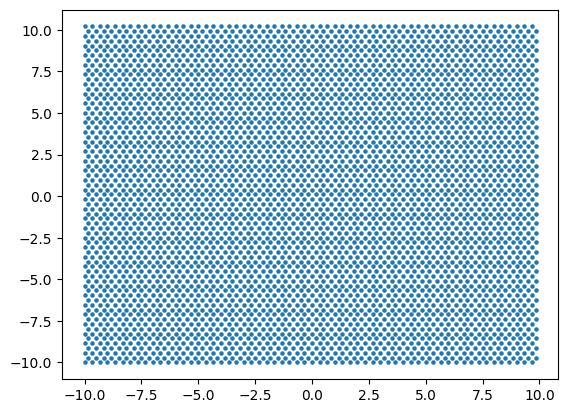

In [69]:
def generate_hex_grid(grid_range=10, grid_resolution=30):
    spacing = 1.0 * grid_range / grid_resolution
    dx = spacing
    dy = spacing * np.sqrt(3.0) / 2.0
    x_vals = np.arange(-grid_range, grid_range + dx, dx)
    y_vals = np.arange(-grid_range, grid_range + dy, dy)
    positions_x = []
    positions_y = []
    for i, y in enumerate(y_vals):
        offset = spacing / 2.0 if i % 2 == 1 else 0.0
        for x in x_vals:
            px = x + offset
            if abs(px) <= grid_range:
                positions_x.append(px)
                positions_y.append(y)
    return np.array(positions_x), np.array(positions_y)


x, y = generate_hex_grid()
print(x.shape)
plt.scatter(x, y, s=5)
plt.show()


In [ ]:
def decode(self, n_particles=80, n_samples=30,
           beta=0.05, gamma=0.1, adam_iter=20, lr=1e-2,
           anchor_weight=1.0, hessian_tau=0.5,
           hessian_every=1, verbose=True):
    self._init_decode_state()
    glm_ctx = self._glm_ctx
    N_sp = self.H * self.W
    S_param = nn.Parameter(torch.zeros(N_sp, device=self.device, dtype=torch.float32))
    Hessian = torch.zeros((N_sp, N_sp), device=self.device, dtype=torch.float32)
    optimizer = torch.optim.Adam([S_param], lr=lr)
    NT = self.n_steps + 1
    particles = torch.zeros(n_particles, 2, device=self.device)
    weights = torch.ones(n_particles, device=self.device) / n_particles
    self.q_particles = torch.zeros(NT, n_particles, 2, device=self.device)
    self.q_weights = torch.zeros(NT, n_particles, device=self.device)
    self.S_hat_history = np.zeros((NT, N_sp))
    self.img_history = np.zeros((NT, self.img_size, self.img_size))
    for t in range(NT):
        if t > 0:
            S_flat = S_param.detach()
            img = S_flat.reshape(self.img_size, self.img_size)
            S_t = torch.tensor(img,dtype=torch.float32,device=self.device)
            get_rates = lambda cx, cy: glm_rates(
                S_t, cx, cy, glm_ctx,
            )
            particles, weights = propagate_particles(
                particles=particles,
                r_on_t=self.spikes_on[t],
                r_off_t=self.spikes_off[t],
                get_rates=get_rates,
                diff_sigma=self.diff_sigma,
                dt=glm_ctx.dt,
                eps=glm_ctx.eps,
                device=dev,
            )
            particles, weights = resample_particles(particles, weights, dev)
        self.q_particles[t] = particles
        self.q_weights[t] = weights
        samples_t = sample_positions(particles, weights, n_samples, dev)
        samples_np = samples_t.cpu().numpy()
        r_on_t = self.r_on_all[t]
        r_off_t = self.r_off_all[t]
        A_anchor = A_param.detach().clone()
        loss_val = adam_update_A(
            glm_ctx=glm_ctx,
            A_param=A_param,
            Hessian=Hessian,
            optimizer=optimizer,
            samples_t=samples_np,
            r_on_t=r_on_t,
            r_off_t=r_off_t,
            A_anchor=A_anchor,
            beta=beta,
            gamma=gamma,
            n_iter=adam_iter,
            img_size=self.img_size,
            mean_offset=self._mean_offset,
            device=dev,
            anchor_weight=cur_anchor_w,
        )
        if (t % hessian_every) == 0:
            A_new = A_param.detach().clone()
            Hessian = update_hessian(
                glm_ctx=glm_ctx,
                H_prev=Hessian,
                A_anchor=A_new,
                samples_t=samples_t,
                r_on_t=r_on_t,
                r_off_t=r_off_t,
                tau=hessian_tau,
                dt=self.dt,
                img_size=self.img_size,
                mean_offset=self._mean_offset,
                device=dev,
            )
        A_np = A_param.detach().cpu().numpy()
        self.A_hat_history[t] = A_np
        self.S_hat_history[t] = (
            A_np.reshape(self.img_size, self.img_size) + self._mean_offset
        )
        if verbose and t % max(T // 10, 1) == 0:
            print(
                f"[decode] t={t}/{T - 1}  loss={loss_val:.3f}  "
                f"||A||_1={np.abs(A_np).sum():.2f}"
            )
    return self.A_hat_history, self.S_hat_history